In [5]:
!pip install pandas matplotlib seaborn nltk wordcloud


[notice] A new release of pip is available: 23.3.2 -> 24.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import pandas as pd

# Load the dataset
file_path = 'data/clean_chatgpt_reviews.csv'  # Replace with your actual file path
df = pd.read_csv(file_path)

# Display the first few rows of the dataset
df.head()


,Unnamed: 0,userName,content,score,thumbsUpCount,at
0,0,T H (Trudylh20),excellent Im impressed 👌 👏,5,0,28-06-2024 21:07
1,1,Muhammad bassam adam,perfect,5,0,28-06-2024 20:56
2,2,Chinaza Okoli,its been so helpful...love it,5,0,28-06-2024 20:54
3,3,Project House Group Ltd,It's amazing tools help me a lot with my work.,5,0,28-06-2024 20:51
4,4,Safoan Riyad,I enjoyed ChatGPT. But last update ruined ever...,1,0,28-06-2024 20:50


In [7]:
# Filter reviews with low ratings (1 or 2)
low_ratings_df = df[df['score'].isin([1, 2])]

# Display the first few rows of the low ratings dataset
low_ratings_df.head()

,Unnamed: 0,userName,content,score,thumbsUpCount,at
4,4,Safoan Riyad,I enjoyed ChatGPT. But last update ruined ever...,1,0,28-06-2024 20:50
14,14,Haroondiamond,good,1,0,28-06-2024 20:09
16,16,Rayyan R,Anytime i try to get the app to work. It tells...,2,0,28-06-2024 19:55
17,17,Kumar T,If I ask any doubts regarding studies it sends...,1,0,28-06-2024 19:51
20,20,Vikas Mutha,It is not working properly.,1,0,28-06-2024 19:36


In [10]:
low_ratings_df.shape

(12144, 6)

In [8]:
# Checking for null values
print("Null values:\n", low_ratings_df.isnull().sum())

Null values:
 Unnamed: 0       0
userName         0
content          0
score            0
thumbsUpCount    0
at               0
dtype: int64


**Temporal Distribution**

C:\Users\Bruger\AppData\Local\Temp\ipykernel_19768\3396702220.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  low_ratings_df['at'] = pd.to_datetime(low_ratings_df['at'])


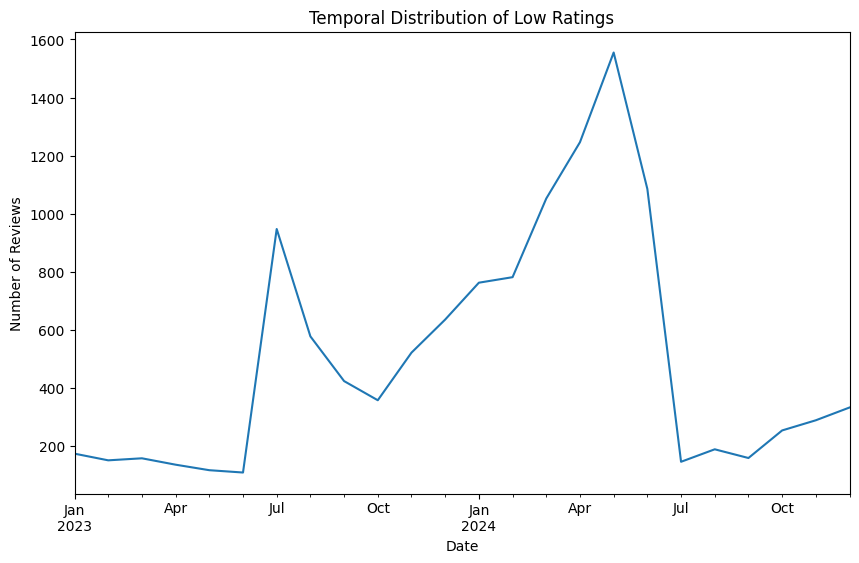

In [9]:
import matplotlib.pyplot as plt

# Convert the 'at' column to datetime
low_ratings_df['at'] = pd.to_datetime(low_ratings_df['at'])

# Plot the temporal distribution
plt.figure(figsize=(10, 6))
low_ratings_df.set_index('at').resample('M').size().plot()
plt.title('Temporal Distribution of Low Ratings')
plt.xlabel('Date')
plt.ylabel('Number of Reviews')
plt.show()


**Content Frequency Analysis**

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Bruger\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Bruger\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


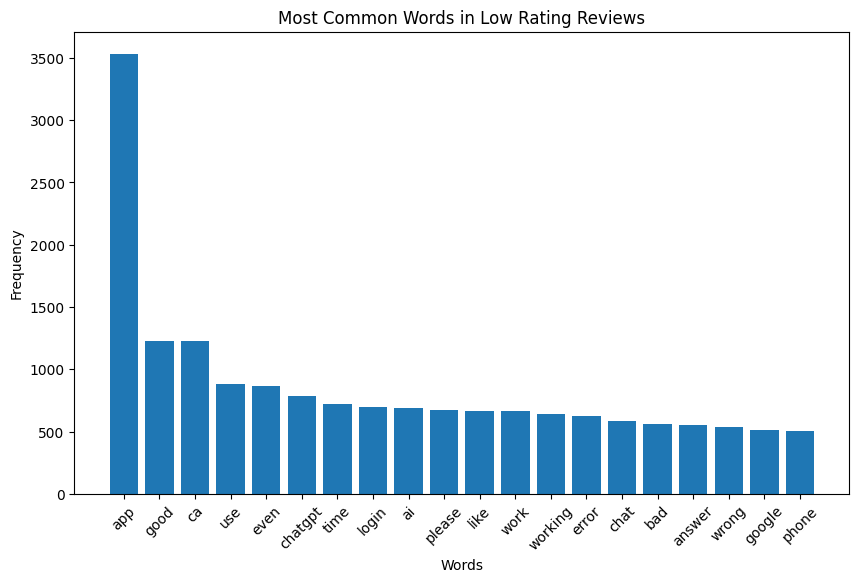

In [14]:
from collections import Counter
import nltk
nltk.download('punkt')
from nltk.corpus import stopwords
import string

nltk.download('stopwords')
stop_words = set(stopwords.words('english') + list(string.punctuation))

# Tokenize the review content and remove stopwords
def tokenize(text):
    tokens = nltk.word_tokenize(text.lower())
    tokens = [word for word in tokens if word.isalpha() and word not in stop_words]
    return tokens

# Get all tokens from low rating reviews
all_tokens = low_ratings_df['content'].apply(tokenize).sum()

# Get the most common words
word_freq = Counter(all_tokens)
most_common_words = word_freq.most_common(20)

# Plot the most common words
words, counts = zip(*most_common_words)
plt.figure(figsize=(10, 6))
plt.bar(words, counts)
plt.title('Most Common Words in Low Rating Reviews')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.show()


**Word Cloud**

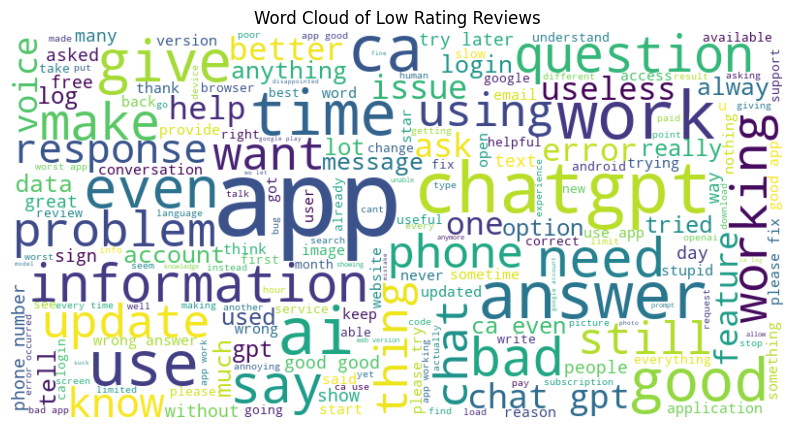

In [15]:
from wordcloud import WordCloud

# Generate a word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(all_tokens))

# Display the word cloud
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Low Rating Reviews')
plt.show()


**Sentiment Analysis**

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\Bruger\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
C:\Users\Bruger\AppData\Local\Temp\ipykernel_1712\2160097081.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  low_ratings_df['sentiment'] = low_ratings_df['content'].apply(lambda x: sia.polarity_scores(x)['compound'])


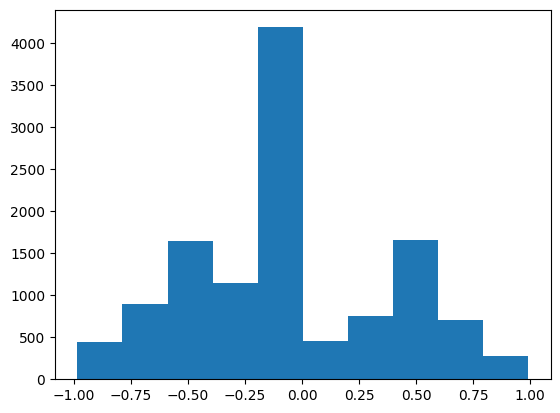

In [20]:

from nltk.sentiment.vader import SentimentIntensityAnalyzer

# Download VADER lexicon
nltk.download('vader_lexicon')

# Initialize the VADER sentiment analyzer
sia = SentimentIntensityAnalyzer()

# Analyze the sentiment of each review
low_ratings_df['sentiment'] = low_ratings_df['content'].apply(lambda x: sia.polarity_scores(x)['compound'])

# Display the sentiment scores
low_ratings_df[['content', 'sentiment']].head()

# Plotting the sentiments
plt.hist(low_ratings_df['sentiment'])
plt.show()


**Most Negative Reviews**

In [12]:
# Select the 10 most upvoted low-rating reviews
top_10_upvoted_reviews = low_ratings_df.nlargest(10, 'thumbsUpCount')[['thumbsUpCount', 'score', 'content', 'at']]
pd.set_option('display.max_colwidth', None)  # This sets no limit on the width of the column
top_10_upvoted_reviews

,thumbsUpCount,score,content,at
38166,941,2,"Still learning this app and everything in it. The bad part is, and it's TERRIBLE, is that for some reason there's a very short limit on a service that costs $20 a month. ""Too many requests to the model"" if you send a certain amount of requests within a certain time frame. More often than not you have to send multiple requests because the ""model"" gets it wrong, then you're locked out for 3 hours. Killer if you're working on a project.. Gotta fix this ASAP on a paid subscription.",2024-01-29 21:34:00
37533,614,2,"I upgraded to the paid version because I wanted more recent results (4/2023 instead some time in 2022). Ever since then it is very slow, halting, stops in the middle of an answer, and frequently provides incorrect and even ludicrous answers. I'm canceling and going back to the free version, which was fantastic. I'd be happy to pay if it worked right. Very disappointing and annoying",2024-03-16 12:19:00
42884,334,2,"Lovely service but I would like to make a few recommendations. Simple interface but it's too basic. Allow the use to have faster access to the previous chats. An interface similar to that of the browser. Consider adding the audio to text option on the free version. This will help train the system and help incorporate more languages into it. Other than this, lovely app and great work on Chatgpt.",2023-08-21 10:52:00
40491,303,1,"It keeps switching me from v4 to v3.5 after the first response, without my consent. This severely limits its usefulness for my use cases. I'm paying to have ongoing discussions with v4! You can't produce good content if you can't have back and forth discussions. I'm severely disappointed. Why am I paying for this? 40 messages / 3 hours was bad enough, but now this... Guys... Be reasonable... 😞 It starts off great then turns into a dunce. Extremely frustrating!!",2023-12-23 08:55:00
37568,284,1,"Don't subscribe!!! Chat GPT Plus charged me twice for my subscription, and I still can't access my account for an urgent project. I've reached out multiple times for help, but no response yet. Past experiences show their support can take up to four months to reply. This delay is unacceptable. If you're considering subscribing, think twice! They need to fix these issues fast. If there's an issue with your subscription there will be no means to quickly fix it due to unavailable customer service.",2024-02-23 10:25:00
38370,212,2,"Edit 2: app can't be used via vpn. Don't bother just use broswer App needs a lot of work compared to browser version. Can't edit chats, can't download pictures, can't get a URL for sharing. Just use it in your phones browser. Edit: can now download pictures in app. Still needs the edit chats feature that is otherwise available in the browser. Would also be nice to be able to get the image URL for sharing like you can in the browser.",2024-02-02 18:14:00
38457,201,1,"I used the app successfully and enjoyed it for several weeks, but now I can't do anything with the app at all. I kept getting a message saying ""request is not allowed."" I updated the app and restarted my phone. Now I can't even login to the app! I get a message saying ""something went wrong. Please make sure your device's date and time settings are set properly. Check that your internet connection is stable, and restart the app."" But none of that gets the app to work. Terrible user experience.",2024-01-26 23:39:00
19572,180,2,"Went from a 6 out of 10, to a 2 out of 10 practically overnight. Canceling my subscription. Out of nowhere image generation is totally broken and refuses to do the simplest things because it goes against their policy. I asked it to make me an image and the style similar to Homer Simpson and it refused. Tried every variation I could think of and it wouldn't do it. Tried several other totally different images and I got the same messages most of the time. Text generation in images is also broken.",2024-05-29 05:08:00
38149,180,2,"It's incre

**Most Recent Reviews**

In [13]:
top_10_upvoted_reviews = low_ratings_df.nlargest(10, 'at')[['thumbsUpCount', 'score', 'content', 'at']]
pd.set_option('display.max_colwidth', None)  # This sets no limit on the width of the column
top_10_upvoted_reviews

,thumbsUpCount,score,content,at
9571,0,1,App work not sjows balck when opene I don't like fix ur app,2024-12-06 22:03:00
9579,0,1,"Not working anymore, For the price we pay, it shouldn't be such a hassle.",2024-12-06 21:36:00
9584,0,1,Its a disaster,2024-12-06 21:15:00
9589,0,2,"Biased. So biased it's obvious. To the point where I often have to give it the correct, non biased agenda. Definitely trying to push a agenda",2024-12-06 21:05:00
9592,0,1,"When i download it, it keeps loading and do not respond just keeps loading all the time",2024-12-06 21:02:00
9594,0,1,Can't sign in,2024-12-06 20:58:00
9607,0,1,"Very bad experience in app, the website was good, but now the app has very bad experience, it delete all history after pause the app. When open the app the screen is starting annoying",2024-12-06 20:30:00
9613,0,1,How dare you calling it Open AI When you charge for it and have deals with big Corporations,2024-12-06 20:17:00
9617,0,1,This a very useless app I have ever seen!!,2024-12-06 20:08:00
9626,0,1,"I paid multiple accounts the last months. They give a little better service at the start of your subscription but then drastically drop the quality of the answers after the first month generally. Pure garbage, full of non-sense, looks like a broken magnetic tape from a commodore , that can even correctly accept 50 words requests. OpenAI is a joke just as most of the cryptos are.",2024-12-06 19:46:00
